# Linear Regression — Math Intuition First

Day 51 — 90-Day Data Science Roadmap

Building linear regression from scratch with NumPy: the equation, the MSE cost function, and gradient descent — using FC Lahore Lions match data (shots + possession -> goals scored).

## Objective

- Implement the linear regression equation y = w1*x1 + w2*x2 + b manually
- Implement the MSE cost function and understand why the error is squared
- Implement gradient descent from scratch and watch the cost converge
- Visualize the cost-vs-weight bowl shape to confirm the minimum

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# seed for consistency across all sessions
np.random.seed(42)


## Theory

- **Equation:** `y = w1*x1 + w2*x2 + b` — each weight says how much that feature moves the prediction; `b` is the baseline.
- **Cost function (MSE):** mean of `(y_pred - y_actual)^2` — squaring keeps errors positive and penalizes big misses harder.
- **Gradient descent:** repeatedly compute the gradient of MSE w.r.t. each weight, then step opposite the gradient (downhill) by a fraction (the learning rate) of it.
- **The bowl:** plotting cost vs. a single weight traces a U-shape — the bottom is the best value for that weight.

## Example 1 — Data, Prediction Function, and Initial Cost

In [2]:
# Simulated FC Lahore Lions match stats -> goals scored
n_matches = 400
shots = np.random.normal(12, 4, n_matches)
possession = np.random.normal(55, 10, n_matches)

# true relationship: goals depend mostly on shots, a little on possession, plus noise
goals = 0.3 * shots + 0.02 * possession + np.random.normal(0, 1.0, n_matches) + 1.0

X = np.column_stack([shots, possession])
y = goals

# normalize features so gradient descent takes balanced steps across both features
X_mean, X_std = X.mean(axis=0), X.std(axis=0)
X_norm = (X - X_mean) / X_std

def predict(X, w, b):
    """y = X . w + b"""
    return X @ w + b

def mse(y_pred, y_true):
    """Mean Squared Error"""
    return np.mean((y_pred - y_true) ** 2)

# start with weights and bias at zero
w = np.array([0.0, 0.0])
b = 0.0

y_pred_init = predict(X_norm, w, b)
print("First 3 predictions (untrained):", np.round(y_pred_init[:3], 3))
print("Initial MSE:", round(mse(y_pred_init, y), 3))


First 3 predictions (untrained): [0. 0. 0.]
Initial MSE: 36.447


## Example 2 — Gradients and One Gradient Descent Step

In [3]:
def gradients(X, y_pred, y_true):
    """Partial derivatives of MSE w.r.t. weights and bias."""
    n = len(y_true)
    error = y_pred - y_true
    dw = (2 / n) * (X.T @ error)
    db = (2 / n) * np.sum(error)
    return dw, db

dw, db = gradients(X_norm, y_pred_init, y)
print("Initial gradients -> dw:", np.round(dw, 3), " db:", round(db, 3))

learning_rate = 0.1
w_step1 = w - learning_rate * dw
b_step1 = b - learning_rate * db

y_pred_step1 = predict(X_norm, w_step1, b_step1)
print("After ONE gradient descent step -> w:", np.round(w_step1, 3), " b:", round(b_step1, 3))
print("MSE after one step:", round(mse(y_pred_step1, y), 3))


Initial gradients -> dw: [-2.187 -0.169]  db: -11.701
After ONE gradient descent step -> w: [0.219 0.017]  b: 1.17
MSE after one step: 23.692


## Practice Exercise

Try it yourself:

1. Change `learning_rate` to `1.5` and re-run the full training loop below. What happens to the cost — does it still converge?
2. Skip feature normalization (use raw `X` instead of `X_norm`) and re-train. How many epochs does it take before the cost looks similar to the normalized version, if it converges at all?

In [4]:
# Your code here




## Mini Challenge

Run the full gradient descent loop for 500 epochs, track the cost at every epoch, and plot cost vs. epoch (the "convergence curve"). Then sweep the first weight (shots) across a range while holding the second weight and bias fixed at their trained values, and plot cost vs. that weight to see the bowl shape directly.

Final weights: [1.117 0.211]  Final bias: 5.85
Final MSE: 0.981


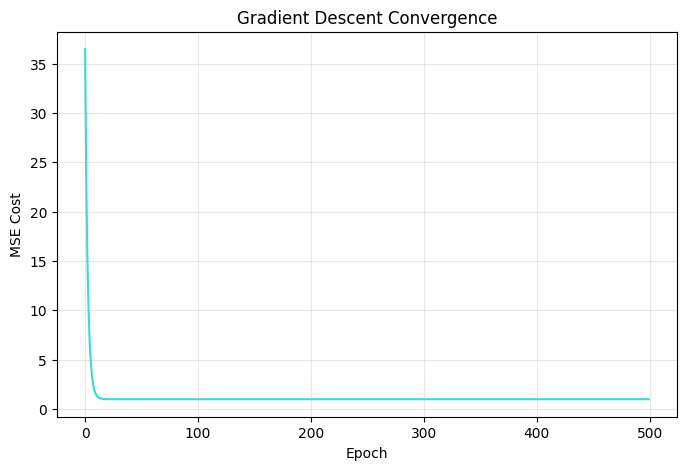

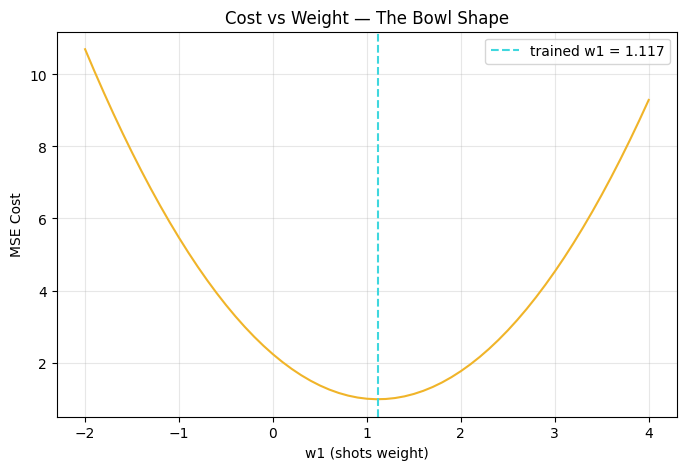

Minimum cost on sweep at w1 = 1.1  cost = 0.982


In [5]:
# Full training loop
w = np.zeros(2)
b = 0.0
learning_rate = 0.1
epochs = 500
cost_history = []

for epoch in range(epochs):
    y_pred = predict(X_norm, w, b)
    cost = mse(y_pred, y)
    cost_history.append(cost)
    dw, db = gradients(X_norm, y_pred, y)
    w -= learning_rate * dw
    b -= learning_rate * db

print("Final weights:", np.round(w, 3), " Final bias:", round(b, 3))
print("Final MSE:", round(cost_history[-1], 3))

# Convergence curve
plt.figure(figsize=(8, 5))
plt.plot(cost_history, color="#3fd7de")
plt.xlabel("Epoch")
plt.ylabel("MSE Cost")
plt.title("Gradient Descent Convergence")
plt.grid(alpha=0.3)
plt.show()

# Cost vs weight sweep (the "bowl") for the shots weight
w1_range = np.linspace(-2, 4, 61)
sweep_costs = [mse(predict(X_norm, np.array([w1_val, w[1]]), b), y) for w1_val in w1_range]

plt.figure(figsize=(8, 5))
plt.plot(w1_range, sweep_costs, color="#f0b429")
plt.axvline(w[0], color="#3fd7de", linestyle="--", label=f"trained w1 = {round(w[0],3)}")
plt.xlabel("w1 (shots weight)")
plt.ylabel("MSE Cost")
plt.title("Cost vs Weight — The Bowl Shape")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_idx = int(np.argmin(sweep_costs))
print("Minimum cost on sweep at w1 =", round(w1_range[best_idx], 3), " cost =", round(sweep_costs[best_idx], 3))


## Summary

- The linear regression equation is a weighted sum plus a bias — training just means finding the best weights and bias.
- MSE squares the error so big mistakes are penalized more and the cost surface stays smooth for gradient descent.
- Gradient descent works by repeatedly stepping opposite the gradient until the cost stops improving.
- The cost-vs-weight sweep confirmed the bowl shape, and the trained weight landed almost exactly at the bottom.
- Next: building on this same loop for logistic regression.